In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import dill

import pickle

import optuna

from collections import deque

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, auc, accuracy_score, roc_curve

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.utils import resample
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression, Lasso

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, VotingClassifier, RandomForestClassifier


from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, FunctionTransformer


from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from matplotlib.gridspec import GridSpec
from sklearn.metrics import brier_score_loss

In [6]:
class TrainDataset:

    def __init__(self, path_to_dataset: str, file_startswith: str) -> None:
        self.path_to_dataset = path_to_dataset
        self.file_startswith = file_startswith
        self.train_data = None

        try:
            dataset_paths = sorted([os.path.join(self.path_to_dataset, filename) for filename in os.listdir(self.path_to_dataset)\
                             if filename.startswith(self.file_startswith)])
            
            dataset_path_list = sorted(dataset_paths, key=len)

            data_list = []
            for path in tqdm.tqdm(dataset_path_list):
                chunk = pd.read_parquet(path)
                data_list.append(chunk)
            
            self.train_data = pd.concat(data_list).reset_index(drop=True)
        

        except FileNotFoundError as e:
            print("Error: The specified file was not found.")


In [7]:
class Config:
    PATH_TO_DATASET = 'data/'
    FILE_STARTWITH = 'train_data'
    
    PATH_TO_PREP_DATASET = 'preprocessed_train_data/'
    PREP_FILE_STARTWITH = 'preprocessed_data'

    SKLEARN_MODEL_PATH = 'sklearn_models'
    TORCH_MODEL_PATH = 'torch_models'

In [8]:
td = TrainDataset(
    path_to_dataset=Config.PATH_TO_DATASET,
    file_startswith=Config.FILE_STARTWITH
)

100%|███████████████████████████████████████████| 12/12 [00:03<00:00,  3.61it/s]


In [9]:
train_df = td.train_data

train_df.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,...,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,...,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,...,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,...,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,...,3,3,3,4,1,3,4,1,0,0


In [10]:
train_df.shape

(26162717, 61)

In [11]:
class DataPreprocessor:

    def __init__(self, train_data: pd.DataFrame, feature_max_value_dict=None) -> None:
        self.train_data = train_data
        self.feature_max_value_dict = feature_max_value_dict


    def save_preprocessed_datasets(self, save_to_path: str) -> None:

        try:
            if self.feature_max_value_dict is None:
                self.feature_max_value_dict = self.get_max_value_dict()
                    
            
            df_list = []
            for col_name, array_size in tqdm.tqdm(self.feature_max_value_dict.items()):
                """
                Формирование списка из датасетов с подсчитанными уникальными значениями каждого признака
                для каждого `id`.
                """

                df = self.unique_feature_value_counter(
                    col_name=col_name,
                    array_size=array_size
                )
                
                df_list.append(df)
    
                """
                Формирование и сохранение предобработанного датасета.
                """

            df_rn_count = self.train_data.groupby(['id'], as_index=False).agg({'rn': 'count'}).reset_index(drop=True)
            
            df_train = pd.concat([df_rn_count] + df_list, axis=1)
    
            df_train.to_parquet(os.path.join(save_to_path, f'preprocessed_data.parquet'))    

        except FileNotFoundError as e:
            print("Dataset list is empty.")
        
    
    def get_max_value_dict(self) -> dict:

        """
        Формирование словаря: 
            ключ - название признака,
            значение - максимальное значение признака всей выборки + 1
        """
        
        max_value_dict = {}
        
        for col in self.train_data.columns[2:]:
            
            s = set()
            max_value = self.train_data[col].max()
            s.add(max_value)
            
            if col not in max_value_dict:
                max_value_dict[col] = max(s) + 1
    
        return max_value_dict

   
    def unique_feature_value_counter(self, col_name: str, array_size: int) -> pd.DataFrame:
        """
        Подсчет количества уникальных значений признака для каждого `id`.
        Формирование датасета:
            колонки - название признака + уникальное значение,
            строки - количество уникального значения для каждого `id`.
        """
        
        array_ = self.train_data[['id', col_name]].to_numpy()
        
        data = {}
        for i, j in array_:
            if i not in data:
                data[i] = np.zeros(array_size)
            data[i][j] += 1
    
        df = pd.DataFrame(data=data.values(), columns=[str(i) + '_' + col_name for i in range(array_size)])
    
        return df   

In [12]:
data_preprocessor = DataPreprocessor(train_df)
data_preprocessor.save_preprocessed_datasets(save_to_path=Config.PATH_TO_PREP_DATASET)

100%|███████████████████████████████████████████| 59/59 [19:36<00:00, 19.94s/it]


In [13]:
train_data = pd.read_parquet(Config.PATH_TO_PREP_DATASET + 'preprocessed_data.parquet')

print(train_data.shape)

(3000000, 442)


In [14]:
target = pd.read_csv('data/train_target.csv')

full_dataset = pd.merge(left=target, right=train_data, on='id')

full_dataset.head()

,id,flag,rn,0_pre_since_opened,1_pre_since_opened,2_pre_since_opened,3_pre_since_opened,4_pre_since_opened,5_pre_since_opened,6_pre_since_opened,...,6_enc_loans_credit_type,7_enc_loans_credit_type,0_enc_loans_account_cur,1_enc_loans_account_cur,2_enc_loans_account_cur,3_enc_loans_account_cur,0_pclose_flag,1_pclose_flag,0_fclose_flag,1_fclose_flag
0,0,0,10,0.0,1.0,1.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,10.0,0.0,0.0,9.0,1.0,8.0,2.0
1,1,0,14,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,14.0,0.0,0.0,13.0,1.0,12.0,2.0
2,2,0,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,1.0,2.0,1.0,2.0
3,3,0,15,0.0,3.0,1.0,0.0,2.0,1.0,3.0,...,0.0,0.0,0.0,15.0,0.0,0.0,10.0,5.0,9.0,6.0
4,4,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [15]:
full_dataset.shape

(3000000, 443)

In [16]:
max_value_dict = data_preprocessor.feature_max_value_dict

with open('prep_params/max_value_dict.pkl', 'wb') as file:
    pickle.dump(max_value_dict, file)

In [18]:
(full_dataset['flag'].value_counts() / len(full_dataset)) * 100

flag
0    96.451933
1     3.548067
Name: count, dtype: float64

In [19]:
"""
MinMaxScaler.
"""
class MMScaler(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        self.scaler = MinMaxScaler()
        self.scaler.fit(X)
        return self

    def transform(self, X):
        X = X.copy()
        df = pd.DataFrame(data=self.scaler.transform(X), columns=X_train.columns)
        return df


"""
Класс для уменьшения размерности.
"""
class DataResample(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_min = X[X['flag'] == 1]
        df_maj = X[X['flag'] == 0]
        df_downupsample = resample(df_maj, replace=True, n_samples=len(df_min), random_state=42)

        return pd.concat([df_min, df_downupsample], ignore_index=True).sample(frac=1.)


"""
Функция разделяет выборки на df_train и df_test, 
понижает размерность df_train, сохраняет и возвращает обе выборки.
"""
def save_and_get_resampled_df(df: pd.DataFrame, random_state: int, save_to_path=None) -> tuple[pd.DataFrame]:
    df_train, df_test = train_test_split(df, test_size=0.25, stratify=df['flag'], random_state=random_state)

    df_downsample = DataResample()

    df_train = df_downsample.fit_transform(df_train)

    if save_to_path:
        df_train.to_parquet(os.path.join(save_to_path, f'training_data.parquet'))
        df_test.to_parquet(os.path.join(save_to_path, f'testing_data.parquet'))

    return df_train, df_test

In [20]:
df_train, df_test = save_and_get_resampled_df(
    df=full_dataset, 
    random_state=3,
    save_to_path=Config.PATH_TO_PREP_DATASET
)

In [21]:
df_train = pd.read_parquet('preprocessed_train_data/training_data.parquet')
df_test = pd.read_parquet('preprocessed_train_data/testing_data.parquet')

print(df_train.shape)
print(df_test.shape)

(159664, 443)
(750000, 443)


In [22]:
df_train.head()

,id,flag,rn,0_pre_since_opened,1_pre_since_opened,2_pre_since_opened,3_pre_since_opened,4_pre_since_opened,5_pre_since_opened,6_pre_since_opened,...,6_enc_loans_credit_type,7_enc_loans_credit_type,0_enc_loans_account_cur,1_enc_loans_account_cur,2_enc_loans_account_cur,3_enc_loans_account_cur,0_pclose_flag,1_pclose_flag,0_fclose_flag,1_fclose_flag
78612,2760538,1,4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,3.0,1.0
100798,1712743,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,3.0,0.0,0.0,3.0,0.0,2.0,1.0
70505,685559,1,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,1.0,2.0
144177,2986671,0,19,1.0,0.0,0.0,1.0,1.0,2.0,0.0,...,0.0,0.0,0.0,19.0,0.0,0.0,18.0,1.0,14.0,5.0
69544,291573,1,15,0.0,2.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,15.0,0.0,0.0,13.0,2.0,13.0,2.0


# feature selection

In [23]:
X = df_train.drop(['id', 'flag'], axis=1)
y = df_train['flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=3, stratify=y
)

scaler = MMScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(data=scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(data=scaler.transform(X_test), columns=X_train.columns)

In [24]:
logreg = LogisticRegression()
logreg_isotonic = CalibratedClassifierCV(logreg, cv=2, method="isotonic")

clf_list = [
    (logreg, "Logistic"),
    (logreg_isotonic, "Logistic isotonic")
]

/var/folders/f4/05vh2j057s91f_5rvhqlwyfc0000gn/T/ipykernel_91623/1268910067.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("Dark2")


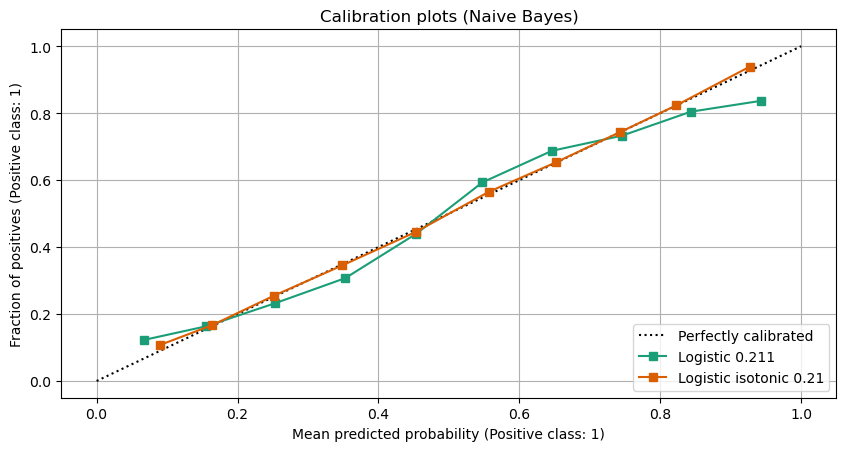

In [25]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.cm.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}

for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    bs = np.round(brier_score_loss(y_test, clf.predict_proba(X_test)[:,1]), 3)

    display = CalibrationDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        n_bins=10,
        name=name + " " + str(bs),
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots (Naive Bayes)");

In [26]:
logreg_isotonic.fit(X_train, y_train)

pred = logreg_isotonic.predict_proba(X_test)[:, 1]

print(roc_auc_score(y_test, pred))

0.7307256138281211


### linear model

In [27]:
f_imp_dict = dict(zip(X_train.columns, logreg_isotonic.calibrated_classifiers_[0].estimator.coef_[0]))
col_to_drop_1 = [k for k, v in f_imp_dict.items() if v == 0]
print(len(col_to_drop_1))

37


In [28]:
X_train_1 = X_train.drop(col_to_drop_1, axis=1)
X_test_1 = X_test.drop(col_to_drop_1, axis=1)

In [29]:
logreg_isotonic.fit(X_train_1, y_train)

pred = logreg_isotonic.predict_proba(X_test_1)[:, 1]

print(roc_auc_score(y_test, pred))

0.7305976343788234


### catboost

In [30]:
cat_model = CatBoostClassifier(verbose=0)

cat_model.fit(X_train_1, y_train)

pred = cat_model.predict_proba(X_test_1)[:, 1]

print(roc_auc_score(y_test, pred))

0.7609887668603516


In [31]:
"""
Функция для получение списка признаков с наименьшим вкладом в предсказания.
"""
def get_unimportant_features(model, threshold: float) -> list:
    
    f_imp_dict = dict(zip(model.feature_names_, model.feature_importances_))
    
    col_to_drop = [k for k, v in f_imp_dict.items() if v <= threshold]
    
    return col_to_drop

In [32]:
"""
Поиск оптимального порога.
"""
score_list = []
thr_list = []

best_score = 0
best_thr = 0
col_to_drop = None

for thr in tqdm.tqdm(np.arange(0.0, 0.21, 0.01)):
    feature_imp_list = get_unimportant_features(model=cat_model, threshold=thr)
    
    X_train_2 = X_train_1.drop(feature_imp_list, axis=1)
    X_test_2 = X_test_1.drop(feature_imp_list, axis=1)

    model = CatBoostClassifier(verbose=0)

    model.fit(X_train_2, y_train)
    
    pred = model.predict_proba(X_test_2)[:, 1]

    score = roc_auc_score(y_test, pred)
        
    score_list.append(score)
    thr_list.append(thr)

100%|███████████████████████████████████████████| 21/21 [12:20<00:00, 35.24s/it]


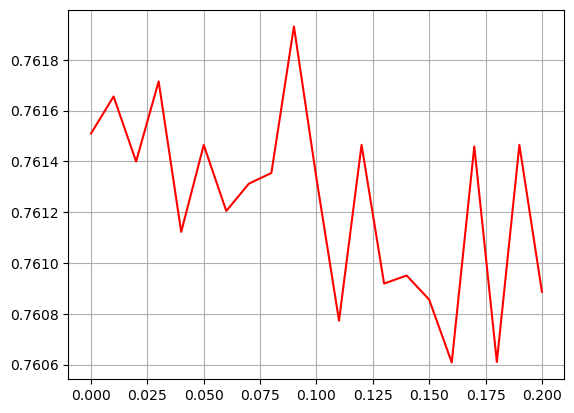

In [33]:
plt.plot(thr_list, score_list, color='red')
plt.grid()
plt.show()

In [34]:
col_to_drop_2 = get_unimportant_features(model=cat_model, threshold=0.09)
len(col_to_drop_2)

150

In [35]:
X_train_2 = X_train_1.drop(col_to_drop_2, axis=1)
X_test_2 = X_test_1.drop(col_to_drop_2, axis=1)

In [36]:
cat_model = CatBoostClassifier(verbose=0)

cat_model.fit(X_train_2, y_train)

pred = cat_model.predict_proba(X_test_2)[:, 1]

print(roc_auc_score(y_test, pred))

0.7619307276917964


In [37]:
col_to_drop = col_to_drop_1 + col_to_drop_2

In [38]:
with open('prep_params/col_to_drop.pkl', 'wb') as file:
    pickle.dump(col_to_drop, file)

# Model selection

In [40]:
X = df_train.drop(col_to_drop + ['id', 'flag'], axis=1)
y = df_train['flag']

X.shape

(159664, 254)

In [41]:
model_list = [
    CatBoostClassifier(verbose=0), 
    XGBClassifier(tree_method='hist'), 
    HistGradientBoostingClassifier(),
    RandomForestClassifier(),
    GradientBoostingClassifier()
]


for model in model_list:
    pipe = Pipeline(steps=[
            ('scaler', MinMaxScaler()),
            ('estimator', model)
        ])


    score = cross_val_score(model, X, y, cv=4, scoring='roc_auc', n_jobs=-1, verbose=False)

    print(score)
    print(f'{model.__class__.__name__} - std_score: {score.std()}, mean_score: {score.mean()}')

[0.75976636 0.75994114 0.75925835 0.7644478 ]
CatBoostClassifier - std_score: 0.0020903199542446353, mean_score: 0.7608534102093403
[0.75158067 0.75051489 0.74832039 0.75719201]
XGBClassifier - std_score: 0.0032725927983900476, mean_score: 0.7519019868319322
[0.7551142  0.75552476 0.75330422 0.75871461]
HistGradientBoostingClassifier - std_score: 0.0019491319859487424, mean_score: 0.7556644444364331
[0.74497934 0.7437882  0.74227715 0.75024283]
RandomForestClassifier - std_score: 0.002998150986151406, mean_score: 0.7453218809680708
[0.74444049 0.74551795 0.74377573 0.75026248]
GradientBoostingClassifier - std_score: 0.0025387286509603747, mean_score: 0.7459991625639617


# Optuna

In [42]:
def objective_rf(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 7, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1e-1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 1500, 2500)
    }

    pipe = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('estimator', CatBoostClassifier(eval_metric='AUC', verbose=0, **params))
    ])
    
    score = cross_val_score(
        pipe, X, y, cv=4, 
        scoring='roc_auc', n_jobs=-1, verbose=False
    ).mean()
        
    return score

cat_study = optuna.create_study(direction='maximize')
cat_study.optimize(objective_rf, n_trials=15)

[I 2026-07-25 20:03:39,556] A new study created in memory with name: no-name-962e1409-c25b-4209-b75d-06150ca66c35
[I 2026-07-25 20:07:00,970] Trial 0 finished with value: 0.7611877112368884 and parameters: {'max_depth': 7, 'learning_rate': 0.02256281280994516, 'n_estimators': 1757}. Best is trial 0 with value: 0.7611877112368884.
[I 2026-07-25 20:22:04,917] Trial 1 finished with value: 0.7634671639483902 and parameters: {'max_depth': 10, 'learning_rate': 0.015155866715224732, 'n_estimators': 2017}. Best is trial 1 with value: 0.7634671639483902.
[I 2026-07-25 20:37:05,322] Trial 2 finished with value: 0.7638652033334539 and parameters: {'max_depth': 10, 'learning_rate': 0.04605642233935361, 'n_estimators': 1947}. Best is trial 2 with value: 0.7638652033334539.
[I 2026-07-25 20:50:19,331] Trial 3 finished with value: 0.7646244017437119 and parameters: {'max_depth': 10, 'learning_rate': 0.02550652838832542, 'n_estimators': 1784}. Best is trial 3 with value: 0.7646244017437119.
[I 2026-07

In [43]:
print(cat_study.best_value)
print(cat_study.best_params)

0.7651935791537617
{'max_depth': 10, 'learning_rate': 0.01763368727949608, 'n_estimators': 2452}


In [44]:
pipe = Pipeline(steps=[
        ('scaler', MinMaxScaler()),
        ('estimator', CatBoostClassifier(eval_metric='AUC', verbose=0, **cat_study.best_params))
    ])

X_test = df_test.drop(col_to_drop + ['id', 'flag'], axis=1)
y_test = df_test['flag']

pipe.fit(X, y)

,steps,"[('scaler', ...), ('estimator', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [45]:
pred = pipe.predict_proba(X_test)[:, 1]

print(roc_auc_score(y_test, pred))

0.7632663653514247


In [46]:
with open('best_pipe/best_model.pkl', 'wb') as file:
    pickle.dump(pipe, file)